# PlantVillage Disease Classification

<p align="right">
Run Time: ~10 minutes
</p>

This notebook walks through benchmarking a model on the **PlantVillage** dataset,
targeting Akida 1 hardware.

For details on the dataset and preparation of the model, see the neighbouring README.md
and plant_village_notebook_training.ipynb.

## Model

A pretrained Akida model is included in this repo, at 
`pretrained_models/akidanet_plant_village_qat.fbz`. As with all model files in the repo, 
that is handled via `git-lfs` (for efficient large file storage). If you haven't set that 
up yet, see the [Trained models](../../../README.md#trained-models) section of the 
top-level README.

If you have run through the training scripts or notebook, and prefer to benchmark the 
Akida model generated through that, simply modify the model directory and filename in the
following cell:

In [1]:
import akida
import os
import numpy as np

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')

DATA_PATH = './data/plant_village'
MODELS_DIR = './pretrained_models/'
MODEL_FILENAME = 'akidanet_plant_village_qat.fbz'
akida_model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)

SEED = 42

To load the model, we simply have to pass the path to the `.fbz` file to the `akida.Model()`
method:

In [2]:
# Load the Akida model
akida_model = akida.Model(akida_model_path)

## Dataset

The **PlantVillage** dataset is loaded via TensorFlow Datasets (`plant_village`).
On the first run, TFDS will automatically download and prepare the dataset to
`DATA_PATH`. Subsequent runs read from the local cache.

The dataset is split 80/10/10 (train/val/test). Images are resized from variable
original sizes to **224 × 224 RGB** and delivered as uint8 pixel values (0–255).

To pre-download without training, run:
```bash
python -c "import tensorflow_datasets as tfds; tfds.load('plant_village', data_dir='./data/plant_village')"
```

In [13]:
from plant_village_data import get_data

INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32

train_ds, val_ds, test_ds = get_data(DATA_PATH, input_shape=INPUT_SHAPE, batch_size=BATCH_SIZE, seed=SEED)
print('Datasets ready.')

Datasets ready.


## Evaluation of Akida Model

We now run evaluation through the Akida model, to check that accuracy is 
comparable to that obtained from the quantized tf_keras model. If an Akida 1
hardware device is connected, it will be used for inference; if not, the
code will fall back to using the software backend: this delivers a
bit-accurate simulation of the results that will be obtained when running
the model on hardware. Let's run that check before going any further

### Check for a connected Akida hardware device

We can use the `akida.devices()` function to detect connected hardware devices.
That returns a list - if it's empty, there were no hardware devices. Otherwise, 
typically we'd only have a single Akida device connected on a given machine, 
and we can just select the first (and only) device returned.

In [4]:
import akida
devices = akida.devices()
if len(devices)>0:
    # Hardware is available
    device = devices[0]
else:
    # Hardware is not available
    device = None

In the present case, we want to be a bit more careful and ensure that the
device is the right version for the model we want to test (here, Akida IP
version 1). We'll import a local function to do that - check out the details 
if interested

In [5]:
from brainchip_utils.hardware_utils import get_akida_device

# Look for a matching hardware device
device = get_akida_device(target_version = akida_model.ip_version)
if device is not None:
    akida_model.map(device, mode=akida.MapMode.AllNps, hw_only=True)

Target Akida device found


### Run Evaluation on Akida

The Akida runtime cannot consume `tf.data.Dataset` objects directly. Rather
it expects a 4D numpy array (n, h, w, c) in uint8 format, so we
iterate over test batches manually. Obviously that situation arises because
the dataset is acquired here in tensorflow format. In a more representative
deployment situation, images would be acquired and sent to Akida without
ever going via the tensorflow dataset format.

The model output tensor has shape `(B, 1, 1, C)` which is squeezed to 
`(B, C)` before taking the class argmax.



In [6]:
from tqdm import tqdm

labels_all = []
logits_all = []
for batch, label_batch in tqdm(test_ds, desc="Evaluating on Akida"):
    if not isinstance(batch, np.ndarray):
        batch = batch.numpy()

    logits_batch = akida_model.predict(batch, batch_size=1)

    logits_batch = logits_batch.squeeze(axis=(1, 2))
    labels_all.append(label_batch)
    logits_all.append(logits_batch)

labels_all = np.concatenate(labels_all)
logits_all = np.concatenate(logits_all)
preds = np.argmax(logits_all, axis=1)

akida_acc = float(np.mean(preds == np.array(labels_all)))
print(f'Akida accuracy: {akida_acc:.4f}')

Evaluating on Akida: 100%|██████████| 170/170 [04:21<00:00,  1.54s/it]

Akida accuracy: 0.9943


### Activation Sparsity

Akida hardware skips computation for zero-valued activations, so activation
sparsity directly reduces both energy consumption and inference latency.
Below we measure per-layer sparsity on a 100-sample calibration batch drawn
from the training set.

In [7]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity
from plant_village_data import get_samples

NUM_SAMPLES = 100

samples = get_samples(DATA_PATH, input_shape=INPUT_SHAPE, num_samples=NUM_SAMPLES)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)


Layer            Sparsity
-------------------------
conv_0            31.83%
conv_1            51.38%
conv_2            57.84%
conv_3            43.97%
separable_4       41.81%
separable_5       64.18%
separable_6       44.12%
separable_7       56.34%
separable_8       62.88%
separable_9       67.96%
separable_10      76.68%
separable_11      62.30%
separable_12      88.24%
separable_13      63.78%
fc_1              59.94%
predictions        0.03%
-------------------------
Mean              54.58%


## Hardware Benchmark

**These cells require a physical AKD1500 device to be connected.** If `device is
None` (reported in the evaluation section above), skip ahead to the Summary.

Akida is an event-driven architecture: computations scale with the number of
non-zero activations, not with tensor size. That means benchmark results are
*input-dependent* — random or synthetic data would give artificially fast or
slow timings. The `samples` array loaded above (real images from the validation
split) is therefore the correct input to use here.

### Simple Benchmark

The simplest way to time an Akida model is to call `forward` in a loop and
read back two clocks after each inference:

- **System clock** (`time.perf_counter_ns`) — wall time including Python and
  USB/PCIe transfer overhead.
- **On-chip clock** (`akida_model.metrics['inference_clk']`) — raw clock cycles
  counted by the AKD1500 itself. Dividing by the 400 MHz core frequency gives
  the pure compute time.

The two numbers should agree closely; a large divergence would indicate a
transfer or driver bottleneck.

In [8]:
import time

CLOCK_FREQUENCY = 400e6  # 400 MHz for AKD1500

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

    # Run a priming frame, so that the model is loaded to the device
    # and the subsequent benchmarking reflects inference time only
    akida_model.forward(samples[:2])

    inf_clks = []
    inf_times = []
    for i in range(len(samples)):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[i:i+1])
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    mean_inf_clk = np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3  # cycles → ms
    mean_inf_time = np.mean(inf_times) * 1e-6                  # ns → ms
    print(f'Mean inference time (system clock):      {mean_inf_time:.3f} ms')
    print(f'Mean on-chip time (chip clock cycles):   {mean_inf_clk:.3f} ms')

Mean inference time (system clock):      95.940 ms
Mean on-chip time (chip clock cycles):   91.050 ms


### Full Model Benchmark

The loop above is clear, but it misses two things: power consumption and a
comparison between mapping modes. `full_model_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
runs the same timed loop while also coordinating optional INA219 power
measurement in a separate process. It sweeps both `MapMode.Minimal` (fewest
NPs, lowest power) and `MapMode.AllNps` (all NPs, maximum parallelism) so the
trade-off is visible. The multiprocessing and power-meter wiring are
non-trivial and not of interest to most users — consult the source if needed.

In [9]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    map_modes = ['Minimal', 'AllNps']
    POWER_REPEATS = 10
    full_results = {}
    for mm in map_modes:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm}, {POWER_REPEATS} repeat(s))...')
        full_results[mm] = full_model_benchmark(
            akida_model, device, samples, map_mode=map_mode, repeats=POWER_REPEATS)

        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  Mapping: {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('WARNING: model not completely mapped to hardware')

Running full-model benchmark (MapMode=Minimal, 10 repeat(s))...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.
  Supply voltage: 0.805 V
  Power measurement active.
  Repeat 1/10: recording floor (1.0 s)...
  Repeat 1/10 done.
  Repeat 2/10: recording floor (1.0 s)...
  Repeat 2/10 done.
  Repeat 3/10: recording floor (1.0 s)...
  Repeat 3/10 done.
  Repeat 4/10: recording floor (1.0 s)...
  Repeat 4/10 done.
  Repeat 5/10: recording floor (1.0 s)...
  Repeat 5/10 done.
  Repeat 6/10: recording floor (1.0 s)...
  Repeat 6/10 done.
  Repeat 7/10: recording floor (1.0 s)...
  Repeat 7/10 done.
  Repeat 8/10: recording floor (1.0 s)...
  Repeat 8/10 done.
  Repeat 9/10: recording floor (1.0 s)...
  Repeat 9/10 done.
  Repeat 10/10: recording floor (1.0 s)...
  Power process: 6981 ok, 0 errors
  Repeat 10/10 done.

  Mean inference time:    95.889 ms  (σ=1.079 ms)
  Mean on-chip time:      91.041 ms  (36416555 clocks)
  Total inferences ru

The plot below shows one column per map mode: a power trace (if a power meter
was connected) and the hardware mapping layout.

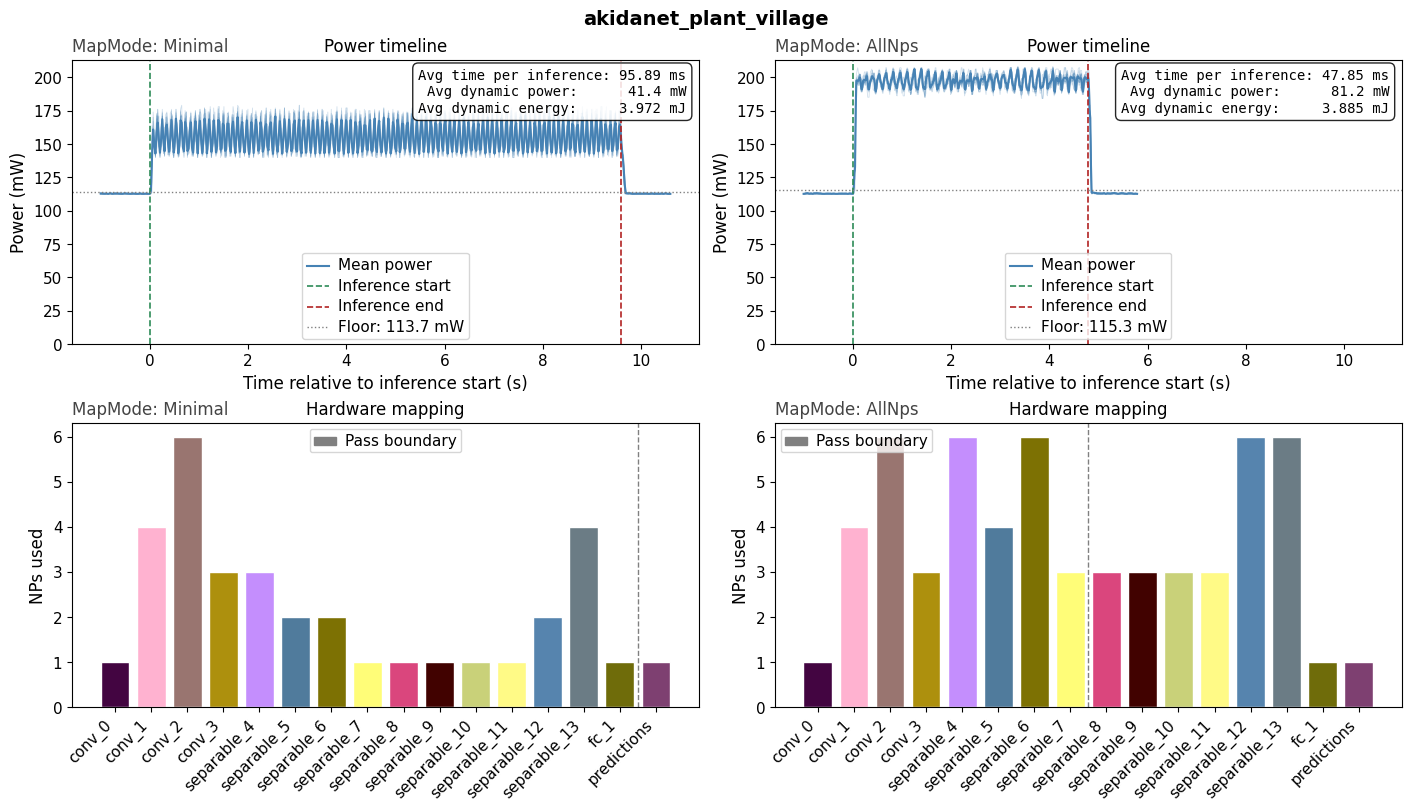

In [10]:
if device is not None:
    plot_full_model_results(full_results, akida_model, device,
                            model_name='akidanet_plant_village')

### Per-Layer Benchmark

Full-model timing tells us the total cost but not where time is spent.
`per_layer_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
reconstructs latency layer by layer by running cumulative sub-models and
differencing the results.

Because Akida processes events (non-zero activations), a layer's cost is
proportional to its *input* sparsity: a layer receiving 90% sparse inputs has
far fewer events to process than one receiving 10% sparse inputs. The per-layer
timing and the sparsity values computed above are therefore naturally correlated —
low-sparsity layers are typically the latency bottlenecks.

In [11]:
from brainchip_utils.hardware_utils import per_layer_benchmark
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so akida_model.sequences is populated for the plot
    akida_model.map(device, mode=akida.MapMode.Minimal)

    print(f'Running per-layer benchmark ({len(samples)} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples)

Running per-layer benchmark (100 samples)...

Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 1.0218
conv_1                 2.1100
conv_2                 4.2227
conv_3                 3.7215
separable_4            9.0689
separable_5            6.9914
separable_6            8.8353
separable_7           12.4627
separable_8            9.9185
separable_9            8.5602
separable_10           7.4962
separable_11           5.6661
separable_12           8.6069
separable_13           0.8553
fc_1                   1.3645
predictions            0.1480
----------------------------------
Total                 91.0502


The plot stacks three panels: per-layer latency, input sparsity per layer, and
the hardware mapping. The inverse relationship between sparsity and latency is
the direct signature of the event-driven compute model: dense activations
generate more events, and more events mean more work for the hardware.

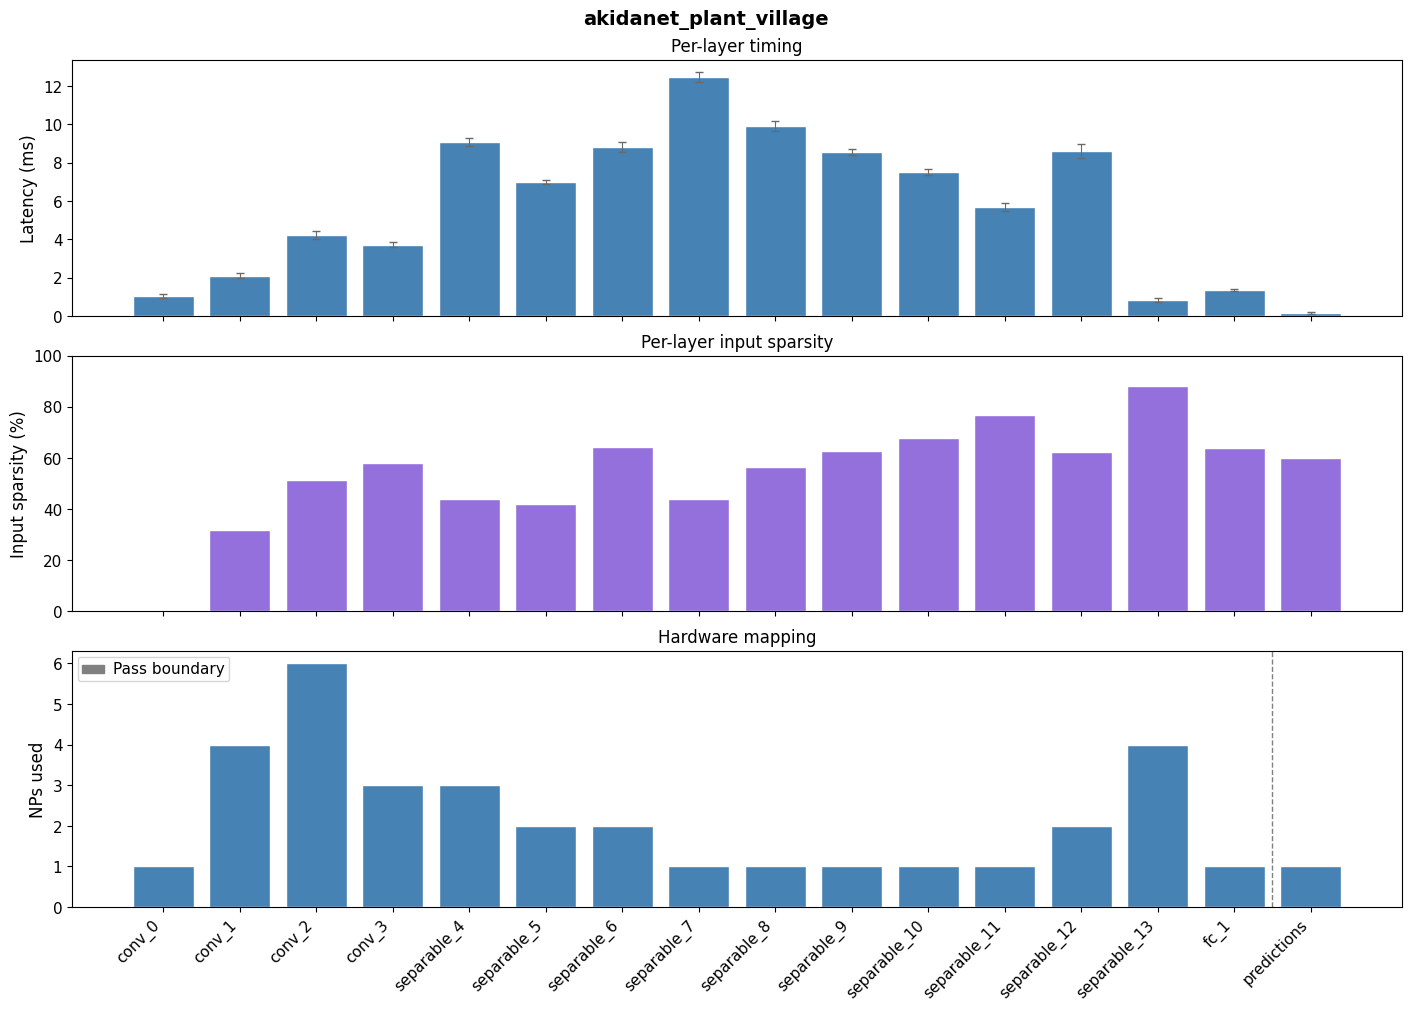

In [12]:
if device is not None:
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name='akidanet_plant_village')